<a href="https://colab.research.google.com/github/Prachii26/DeepLearningCMPE258/blob/main/Deep_learning_training_design_space/Final_cnn_fundamentals_tutorial(Prachi_Gupta).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Networks from First Principles

## A Visual Journey into Computer Vision Deep Learning

---

Welcome to the world of **Convolutional Neural Networks (CNNs)** - the architecture that revolutionized computer vision and enabled machines to truly "see."

### Why CNNs Changed Everything

| Year | Milestone | Impact |
|------|-----------|--------|
| 1998 | LeNet-5 | First successful CNN (digit recognition) |
| 2012 | AlexNet | Won ImageNet by huge margin, sparked deep learning revolution |
| 2014 | VGGNet | Showed depth matters (16-19 layers) |
| 2015 | ResNet | Skip connections enabled 152+ layers |
| 2020 | EfficientNet | Optimal scaling of width/depth/resolution |

### What You'll Learn

| Chapter | Topic | Key Concepts |
|---------|-------|-------------|
| 1 | The Convolution Operation | Kernels, feature maps, edge detection |
| 2 | Building CNN Layers | Conv2d, padding, stride, channels |
| 3 | Pooling & Downsampling | MaxPool, AvgPool, spatial reduction |
| 4 | CNN Architectures | LeNet, AlexNet patterns |
| 5 | Training CNNs | Data augmentation, batch norm |
| 6 | Visualizing What CNNs Learn | Feature maps, filters, Grad-CAM |
| 7 | Complete CIFAR-10 Classifier | End-to-end implementation |

---

*"The key insight of CNNs is that visual patterns are local and hierarchical."*

In [1]:
# ============================================================================
#                           SETUP & IMPORTS
# ============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from typing import List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# Beautiful plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch Version: {torch.__version__}")
print(f"Torchvision Version: {torchvision.__version__}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

PyTorch Version: 2.10.0+cu128
Torchvision Version: 0.25.0+cu128
Device: cuda
GPU: Tesla T4


---

# Chapter 1: The Convolution Operation

## Why Not Use Fully Connected Networks for Images?

Consider a 224x224 RGB image:
- Input size: 224 × 224 × 3 = **150,528** pixels
- First hidden layer with 1000 neurons: 150,528 × 1000 = **150 million** parameters!

### CNNs Solve This with Three Key Ideas:

1. **Local Connectivity**: Each neuron only connects to a small region (receptive field)
2. **Parameter Sharing**: Same filter applied across the entire image
3. **Translation Equivariance**: Detecting a pattern works regardless of position

```
Fully Connected:                    Convolutional:

Every input         →  Every output   Local region    →  One output
connects to                          connects to
every output                         one output

[x x x x x x]  →  [o o o o]          [x x x]  →  [o]
 ↓ ↓ ↓ ↓ ↓ ↓      ↑ ↑ ↑ ↑             ↓ ↓ ↓
 all connected!                      3×3 kernel
```

In [2]:
# ============================================================================
#                    UNDERSTANDING CONVOLUTION
# ============================================================================

print("="*60)
print("           THE CONVOLUTION OPERATION")
print("="*60)

def conv2d_manual(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """
    Perform 2D convolution manually to understand the operation.

    The convolution slides a kernel across the image:

    Image:          Kernel:        Output:
    [1 2 3 4 5]     [1 0 -1]
    [2 3 4 5 6]     [2 0 -2]   →   Slide and sum!
    [3 4 5 6 7]     [1 0 -1]

    At each position:
    output[i,j] = sum(image_patch * kernel)
    """
    img_h, img_w = image.shape
    k_h, k_w = kernel.shape

    # Output size (valid convolution, no padding)
    out_h = img_h - k_h + 1
    out_w = img_w - k_w + 1

    output = np.zeros((out_h, out_w))

    # Slide the kernel across the image
    for i in range(out_h):
        for j in range(out_w):
            # Extract the image patch
            patch = image[i:i+k_h, j:j+k_w]
            # Element-wise multiply and sum
            output[i, j] = np.sum(patch * kernel)

    return output


# Create a simple 5x5 image
image = np.array([
    [10, 10, 10, 0, 0],
    [10, 10, 10, 0, 0],
    [10, 10, 10, 0, 0],
    [10, 10, 10, 0, 0],
    [10, 10, 10, 0, 0]
], dtype=np.float32)

# Vertical edge detection kernel (Sobel-like)
kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

print("\nInput Image (5x5):")
print(image)
print("\nKernel (3x3) - Vertical Edge Detector:")
print(kernel)

# Apply convolution
output = conv2d_manual(image, kernel)
print("\nOutput (3x3):")
print(output)

print("\n The kernel detected the vertical edge!")
print(" High values (30) at columns 1-2 where the edge is.")

           THE CONVOLUTION OPERATION

Input Image (5x5):
[[10. 10. 10.  0.  0.]
 [10. 10. 10.  0.  0.]
 [10. 10. 10.  0.  0.]
 [10. 10. 10.  0.  0.]
 [10. 10. 10.  0.  0.]]

Kernel (3x3) - Vertical Edge Detector:
[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]

Output (3x3):
[[  0. -40. -40.]
 [  0. -40. -40.]
 [  0. -40. -40.]]

 The kernel detected the vertical edge!
 High values (30) at columns 1-2 where the edge is.


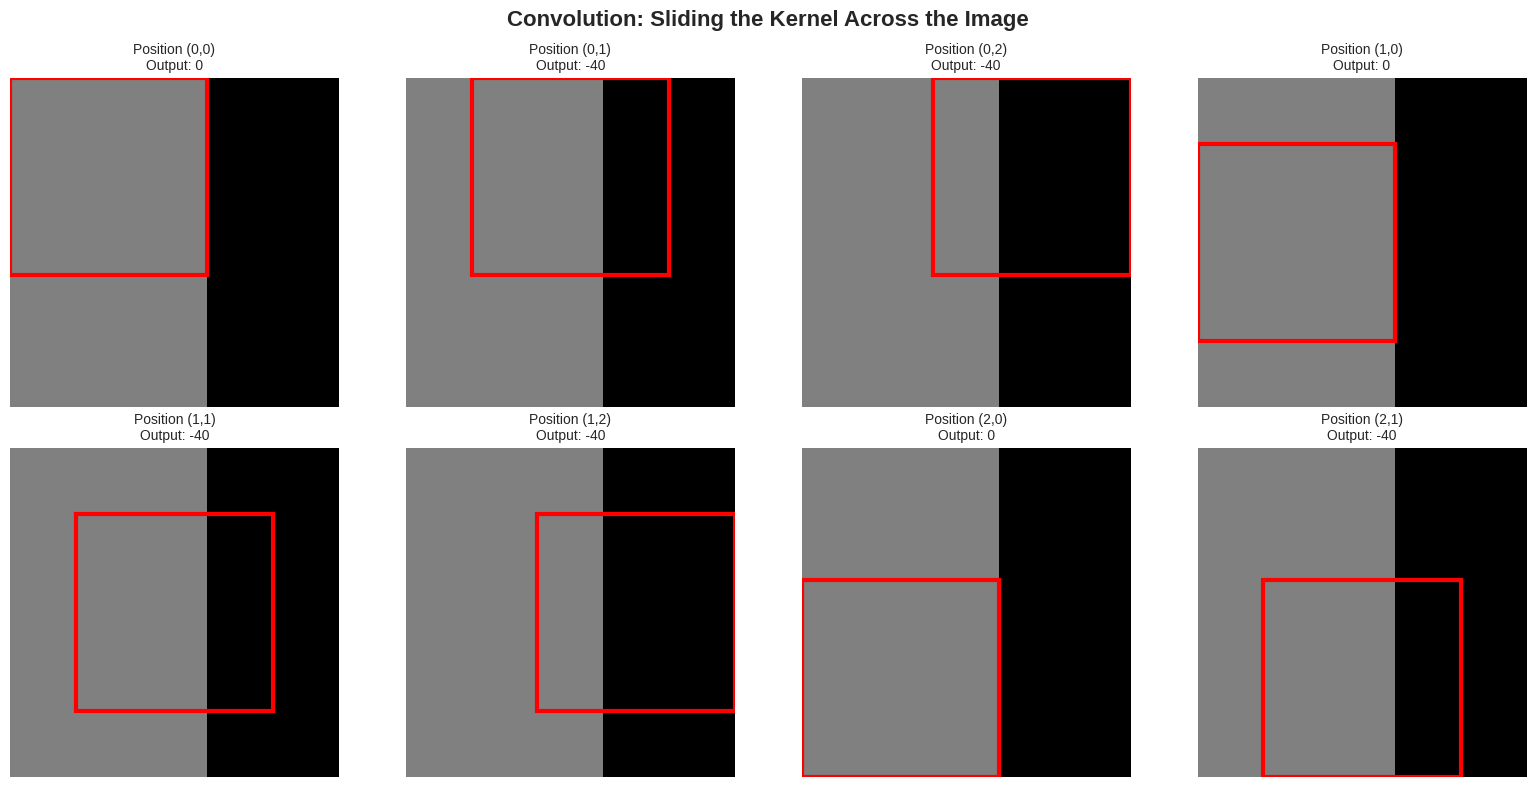

In [3]:
# ============================================================================
#                    VISUALIZING CONVOLUTION
# ============================================================================

def visualize_convolution_step_by_step(image, kernel, title="Convolution"):
    """
    Visualize convolution operation step by step.
    """
    img_h, img_w = image.shape
    k_h, k_w = kernel.shape
    out_h = img_h - k_h + 1
    out_w = img_w - k_w + 1

    output = np.zeros((out_h, out_w))

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    positions = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1)]

    for idx, ax in enumerate(axes.flatten()):
        if idx >= len(positions):
            ax.axis('off')
            continue

        i, j = positions[idx]
        patch = image[i:i+k_h, j:j+k_w]
        result = np.sum(patch * kernel)
        output[i, j] = result

        # Create visualization
        vis = image.copy()

        ax.imshow(vis, cmap='gray', vmin=0, vmax=20)

        # Highlight the current patch
        rect = plt.Rectangle((j-0.5, i-0.5), k_w, k_h,
                            fill=False, color='red', linewidth=3)
        ax.add_patch(rect)

        ax.set_title(f'Position ({i},{j})\nOutput: {result:.0f}', fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    return output


output = visualize_convolution_step_by_step(
    image, kernel,
    "Convolution: Sliding the Kernel Across the Image"
)

           CLASSIC IMAGE KERNELS


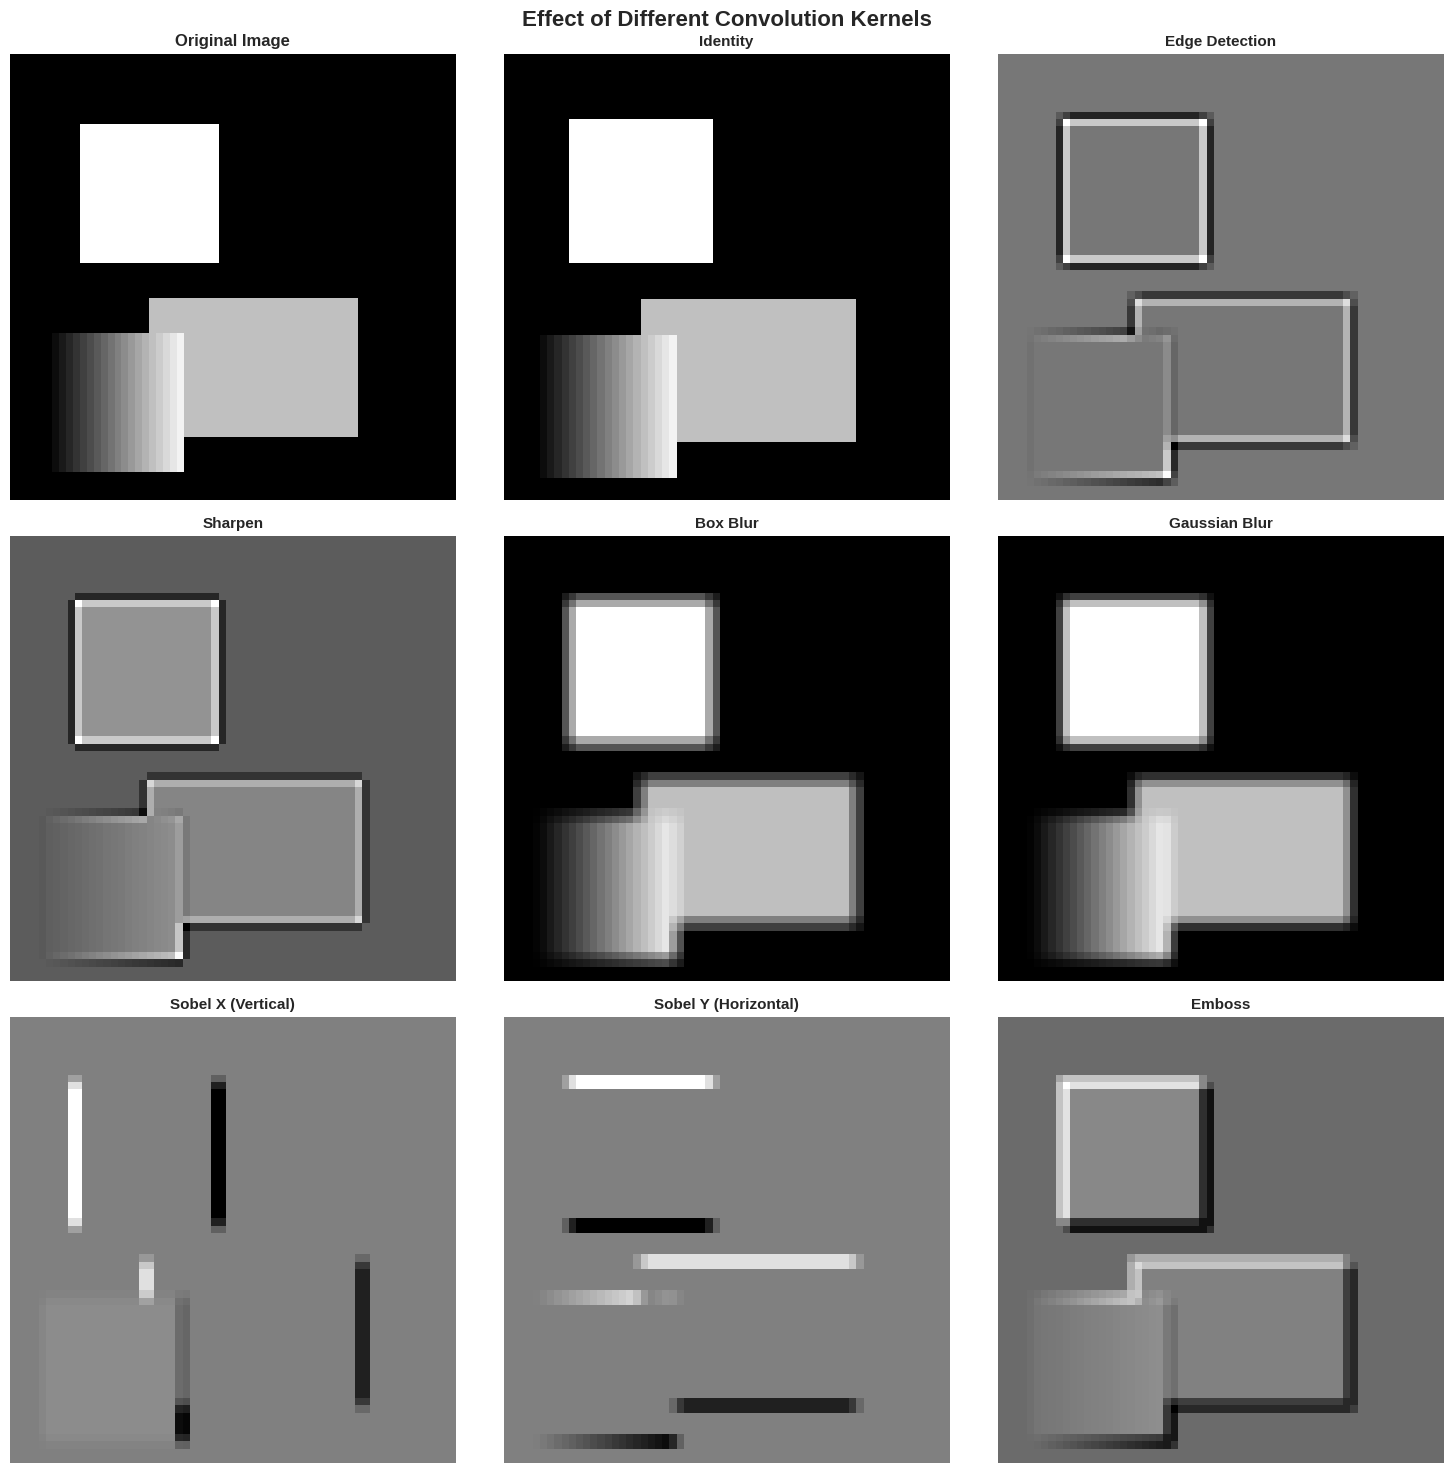


 Key Insight: These are HAND-DESIGNED kernels.
 CNNs LEARN optimal kernels from data!


In [4]:
# ============================================================================
#                    CLASSIC EDGE DETECTION KERNELS
# ============================================================================

print("="*60)
print("           CLASSIC IMAGE KERNELS")
print("="*60)

# Famous kernels used in image processing
kernels = {
    'Identity': np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]]),
    'Edge Detection': np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]]),
    'Sharpen': np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]]),
    'Box Blur': np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]]) / 9,
    'Gaussian Blur': np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]]) / 16,
    'Sobel X (Vertical)': np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]),
    'Sobel Y (Horizontal)': np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]),
    'Emboss': np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]])
}

# Load a sample image
# Create a synthetic image with edges
def create_test_image(size=64):
    img = np.zeros((size, size))
    # Add some shapes
    img[10:30, 10:30] = 200  # Square
    img[35:55, 20:50] = 150  # Rectangle
    # Add gradient
    for i in range(20):
        img[40:60, 5+i] = i * 10
    return img.astype(np.float32)

test_image = create_test_image()

# Apply all kernels
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

axes[0].imshow(test_image, cmap='gray')
axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

for idx, (name, kernel) in enumerate(kernels.items()):
    if idx >= 8:
        break
    result = conv2d_manual(test_image, kernel.astype(np.float32))
    axes[idx + 1].imshow(result, cmap='gray')
    axes[idx + 1].set_title(name, fontsize=11, fontweight='bold')
    axes[idx + 1].axis('off')

plt.suptitle('Effect of Different Convolution Kernels', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Key Insight: These are HAND-DESIGNED kernels.")
print(" CNNs LEARN optimal kernels from data!")

---

# Chapter 2: Building CNN Layers in PyTorch

## The nn.Conv2d Layer

PyTorch's `Conv2d` handles all the complexity for us:

```python
nn.Conv2d(
    in_channels,   # Number of input channels (1 for grayscale, 3 for RGB)
    out_channels,  # Number of filters (feature maps to produce)
    kernel_size,   # Size of the filter (3 means 3x3)
    stride=1,      # Step size when sliding
    padding=0,     # Zeros added around the input
    bias=True      # Add bias term
)
```

### Output Size Formula

$$H_{out} = \lfloor \frac{H_{in} + 2 \times padding - kernel\_size}{stride} \rfloor + 1$$

### Common Patterns

| Goal | kernel_size | stride | padding | Output Size |
|------|-------------|--------|---------|-------------|
| Same size | 3 | 1 | 1 | Same as input |
| Same size | 5 | 1 | 2 | Same as input |
| Halve size | 3 | 2 | 1 | ~Half of input |
| Reduce by 2 | 3 | 1 | 0 | Input - 2 |

In [5]:
# ============================================================================
#                       nn.Conv2d IN DETAIL
# ============================================================================

print("="*60)
print("           nn.Conv2d EXPLAINED")
print("="*60)

# Create a simple Conv2d layer
conv = nn.Conv2d(
    in_channels=1,    # 1 input channel (grayscale)
    out_channels=3,   # 3 output channels (3 different feature maps)
    kernel_size=3,    # 3x3 kernels
    stride=1,         # Move 1 pixel at a time
    padding=1         # Add 1 pixel border of zeros
)

print(f"\nConv2d Layer Configuration:")
print(f"  in_channels:  {conv.in_channels}")
print(f"  out_channels: {conv.out_channels}")
print(f"  kernel_size:  {conv.kernel_size}")
print(f"  stride:       {conv.stride}")
print(f"  padding:      {conv.padding}")

print(f"\nParameter Shapes:")
print(f"  Weight: {conv.weight.shape}")
print(f"          (out_channels, in_channels, kernel_h, kernel_w)")
print(f"  Bias:   {conv.bias.shape}")
print(f"          (out_channels,)")

# Total parameters
total_params = conv.weight.numel() + conv.bias.numel()
print(f"\n  Total Parameters: {total_params}")

# Apply to an image
# Input shape: (batch_size, channels, height, width)
x = torch.randn(1, 1, 28, 28)  # 1 grayscale 28x28 image
y = conv(x)

print(f"\nInput/Output:")
print(f"  Input shape:  {x.shape} (batch, channels, H, W)")
print(f"  Output shape: {y.shape}")
print(f"  With padding=1, size is preserved!")

           nn.Conv2d EXPLAINED

Conv2d Layer Configuration:
  in_channels:  1
  out_channels: 3
  kernel_size:  (3, 3)
  stride:       (1, 1)
  padding:      (1, 1)

Parameter Shapes:
  Weight: torch.Size([3, 1, 3, 3])
          (out_channels, in_channels, kernel_h, kernel_w)
  Bias:   torch.Size([3])
          (out_channels,)

  Total Parameters: 30

Input/Output:
  Input shape:  torch.Size([1, 1, 28, 28]) (batch, channels, H, W)
  Output shape: torch.Size([1, 3, 28, 28])
  With padding=1, size is preserved!


In [6]:
# ============================================================================
#                    PADDING AND STRIDE VISUALIZED
# ============================================================================

print("="*60)
print("           PADDING AND STRIDE EFFECTS")
print("="*60)

# Test different configurations
configs = [
    {'kernel_size': 3, 'stride': 1, 'padding': 0, 'name': 'No padding'},
    {'kernel_size': 3, 'stride': 1, 'padding': 1, 'name': 'Same padding'},
    {'kernel_size': 3, 'stride': 2, 'padding': 1, 'name': 'Stride 2'},
    {'kernel_size': 5, 'stride': 1, 'padding': 2, 'name': '5x5 kernel'},
    {'kernel_size': 5, 'stride': 2, 'padding': 2, 'name': '5x5 + stride 2'},
    {'kernel_size': 7, 'stride': 2, 'padding': 3, 'name': '7x7 + stride 2'},
]

input_size = 32  # 32x32 input
x = torch.randn(1, 3, input_size, input_size)

print(f"\nInput size: {input_size}x{input_size}")
print(f"\n{'Configuration':<20} {'Kernel':<8} {'Stride':<8} {'Padding':<10} {'Output Size':<12}")
print("-"*60)

for cfg in configs:
    conv = nn.Conv2d(
        in_channels=3,
        out_channels=16,
        kernel_size=cfg['kernel_size'],
        stride=cfg['stride'],
        padding=cfg['padding']
    )
    y = conv(x)
    out_size = y.shape[-1]
    print(f"{cfg['name']:<20} {cfg['kernel_size']:<8} {cfg['stride']:<8} {cfg['padding']:<10} {out_size}x{out_size}")

           PADDING AND STRIDE EFFECTS

Input size: 32x32

Configuration        Kernel   Stride   Padding    Output Size 
------------------------------------------------------------
No padding           3        1        0          30x30
Same padding         3        1        1          32x32
Stride 2             3        2        1          16x16
5x5 kernel           5        1        2          32x32
5x5 + stride 2       5        2        2          16x16
7x7 + stride 2       7        2        3          16x16


      MULTI-CHANNEL CONVOLUTION (RGB Images)

For RGB images (3 channels), each filter has 3 sub-kernels:

Input (3 channels):          Filter:                  Output:
                                                      (1 channel)
   R channel      ×    R kernel      G channel      ×    G kernel    |---> SUM ---> Feature Map
   B channel      ×    B kernel   /

With N filters, we get N output feature maps!

Filter shape: (out_channels, in_channels, kernel_h, kernel_w)
            = (N, 3, k, k) for RGB input with N filters


Conv layer for RGB input:
  Weight shape: torch.Size([32, 3, 3, 3])
  = (32 filters, 3 channels each, 3x3 kernel)
  Parameters: 864 weights + 32 biases


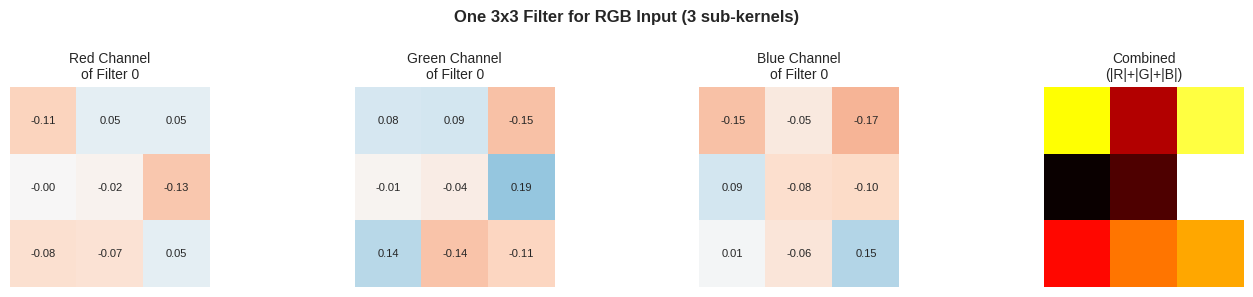

In [7]:
# ============================================================================
#               MULTI-CHANNEL CONVOLUTION EXPLAINED
# ============================================================================

print("="*60)
print("      MULTI-CHANNEL CONVOLUTION (RGB Images)")
print("="*60)

print("""
For RGB images (3 channels), each filter has 3 sub-kernels:

Input (3 channels):          Filter:                  Output:
                                                      (1 channel)
   R channel      ×    R kernel   \
   G channel      ×    G kernel    |---> SUM ---> Feature Map
   B channel      ×    B kernel   /

With N filters, we get N output feature maps!

Filter shape: (out_channels, in_channels, kernel_h, kernel_w)
            = (N, 3, k, k) for RGB input with N filters
""")

# Demonstrate with code
conv_rgb = nn.Conv2d(
    in_channels=3,    # RGB
    out_channels=32,  # 32 different feature maps
    kernel_size=3,
    padding=1
)

# Visualize the weights
print(f"\nConv layer for RGB input:")
print(f"  Weight shape: {conv_rgb.weight.shape}")
print(f"  = (32 filters, 3 channels each, 3x3 kernel)")
print(f"  Parameters: {conv_rgb.weight.numel()} weights + {conv_rgb.bias.numel()} biases")

# Show one filter
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

filter_0 = conv_rgb.weight[0].detach().numpy()  # Shape: (3, 3, 3)

for i, (ax, channel) in enumerate(zip(axes[:3], ['Red', 'Green', 'Blue'])):
    ax.imshow(filter_0[i], cmap='RdBu', vmin=-0.5, vmax=0.5)
    ax.set_title(f'{channel} Channel\nof Filter 0', fontsize=10)
    ax.axis('off')
    for y in range(3):
        for x in range(3):
            ax.text(x, y, f'{filter_0[i, y, x]:.2f}', ha='center', va='center', fontsize=8)

# Combined visualization
axes[3].imshow(np.abs(filter_0).sum(axis=0), cmap='hot')
axes[3].set_title('Combined\n(|R|+|G|+|B|)', fontsize=10)
axes[3].axis('off')

plt.suptitle('One 3x3 Filter for RGB Input (3 sub-kernels)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---

# Chapter 3: Pooling - Spatial Downsampling

## Why Pool?

1. **Reduce spatial dimensions** - Fewer parameters, faster computation
2. **Increase receptive field** - See larger patterns with same kernel size
3. **Translation invariance** - Small shifts don't change output

### Types of Pooling

```
Input (4x4):        Max Pool (2x2):     Avg Pool (2x2):

[1 3 2 4]           [7 8]               [4.5 4.5]
[5 7 6 8]     →                    →
[3 2 1 0]           [5 3]               [3.0 1.5]
[5 4 3 2]

Max: Take maximum value in each 2x2 region
Avg: Take average value in each 2x2 region
```

In [8]:
# ============================================================================
#                        POOLING LAYERS
# ============================================================================

print("="*60)
print("              POOLING OPERATIONS")
print("="*60)

# Create a sample feature map
x = torch.tensor([[[
    [1., 3., 2., 4.],
    [5., 7., 6., 8.],
    [3., 2., 1., 0.],
    [5., 4., 3., 2.]
]]])  # Shape: (1, 1, 4, 4)

print(f"Input (4x4):")
print(x.squeeze().numpy())

# Max Pooling
max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
max_out = max_pool(x)

print(f"\nMax Pool 2x2 (stride 2):")
print(max_out.squeeze().numpy())

# Average Pooling
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)
avg_out = avg_pool(x)

print(f"\nAvg Pool 2x2 (stride 2):")
print(avg_out.squeeze().numpy())

# Adaptive Pooling - output size is fixed!
adaptive_pool = nn.AdaptiveAvgPool2d(output_size=(1, 1))
global_avg = adaptive_pool(x)

print(f"\nGlobal Average Pooling:")
print(f"  Output: {global_avg.squeeze().item():.4f}")
print(f"  = Mean of all values: {x.mean().item():.4f}")

              POOLING OPERATIONS
Input (4x4):
[[1. 3. 2. 4.]
 [5. 7. 6. 8.]
 [3. 2. 1. 0.]
 [5. 4. 3. 2.]]

Max Pool 2x2 (stride 2):
[[7. 8.]
 [5. 3.]]

Avg Pool 2x2 (stride 2):
[[4.  5. ]
 [3.5 1.5]]

Global Average Pooling:
  Output: 3.5000
  = Mean of all values: 3.5000


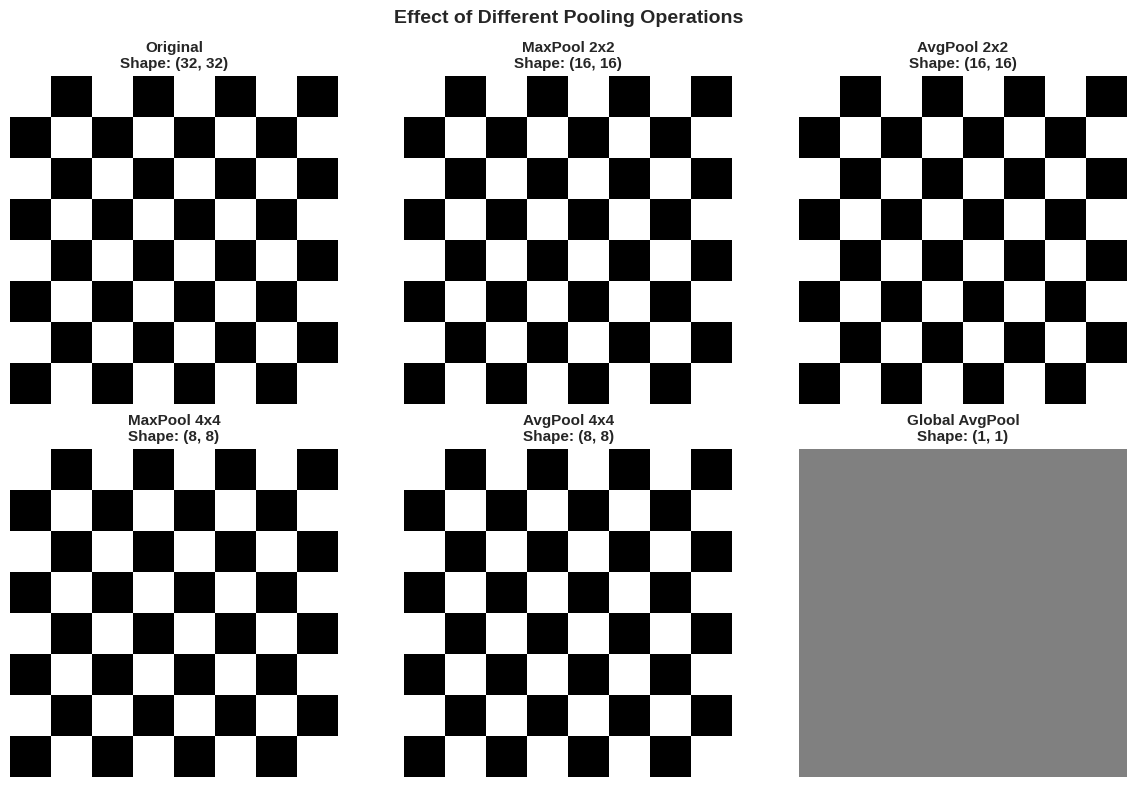


 Max Pool: Preserves sharp patterns (edges, textures)
 Avg Pool: Smoother, less sensitive to noise
 Global Pool: Reduces to single value (used before final FC layer)


In [9]:
# ============================================================================
#                   VISUALIZE POOLING EFFECTS
# ============================================================================

# Create a more interesting image
def create_checkerboard(size=32):
    img = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            if (i // 4 + j // 4) % 2 == 0:
                img[i, j] = 1.0
    return img

# Test image
img = torch.tensor(create_checkerboard(32)).unsqueeze(0).unsqueeze(0).float()

# Different pooling operations
pools = [
    ('Original', None),
    ('MaxPool 2x2', nn.MaxPool2d(2)),
    ('AvgPool 2x2', nn.AvgPool2d(2)),
    ('MaxPool 4x4', nn.MaxPool2d(4)),
    ('AvgPool 4x4', nn.AvgPool2d(4)),
    ('Global AvgPool', nn.AdaptiveAvgPool2d(1))
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, (name, pool) in zip(axes.flatten(), pools):
    if pool is None:
        out = img
    else:
        out = pool(img)

    # Fix: Ensure the tensor is at least 2D before converting to numpy for imshow
    # out.squeeze(0).squeeze(0) will remove the batch and channel dimensions,
    # leaving (H, W) which is suitable for grayscale imshow.
    ax.imshow(out.squeeze(0).squeeze(0).numpy(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'{name}\nShape: {tuple(out.shape[2:])}', fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle('Effect of Different Pooling Operations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Max Pool: Preserves sharp patterns (edges, textures)")
print(" Avg Pool: Smoother, less sensitive to noise")
print(" Global Pool: Reduces to single value (used before final FC layer)")

---

# Chapter 4: Building Complete CNN Architectures

## The Classic CNN Pattern

```
Input Image
    ↓
[Conv → ReLU → Pool] × N     ← Feature extraction
    ↓
Flatten
    ↓
[FC → ReLU] × M              ← Classification
    ↓
Output (softmax)
```

### Feature Pyramid

As we go deeper:
- **Spatial size decreases**: 32×32 → 16×16 → 8×8 → ...
- **Number of channels increases**: 3 → 32 → 64 → 128 → ...
- **Features become more abstract**: edges → textures → parts → objects

In [10]:
# ============================================================================
#                    LeNet-5: THE HISTORIC CNN
# ============================================================================

print("="*60)
print("           LeNet-5 (1998) - THE PIONEER")
print("="*60)

class LeNet5(nn.Module):
    """
    LeNet-5: The CNN that started it all!

    Designed by Yann LeCun for handwritten digit recognition.

    Architecture:

    Input (1, 32, 32)
        ↓
    Conv(6, 5x5) → (6, 28, 28)     # 6 feature maps
        ↓
    Pool(2x2)    → (6, 14, 14)
        ↓
    Conv(16, 5x5) → (16, 10, 10)   # 16 feature maps
        ↓
    Pool(2x2)    → (16, 5, 5)
        ↓
    Flatten      → (400,)
        ↓
    FC(120)      → (120,)
        ↓
    FC(84)       → (84,)
        ↓
    FC(10)       → (10,)          # 10 digit classes
    """

    def __init__(self, num_classes: int = 10):
        super().__init__()

        # Feature extraction layers
        self.features = nn.Sequential(
            # Layer 1: Conv + Pool
            nn.Conv2d(1, 6, kernel_size=5),       # 32 → 28
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2), # 28 → 14

            # Layer 2: Conv + Pool
            nn.Conv2d(6, 16, kernel_size=5),      # 14 → 10
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2), # 10 → 5
        )

        # Classifier layers
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),
            nn.Tanh(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x


# Create and analyze
lenet = LeNet5()

# Count parameters
total_params = sum(p.numel() for p in lenet.parameters())
print(f"\nLeNet-5 Architecture:")
print(lenet)
print(f"\nTotal Parameters: {total_params:,}")

# Test forward pass
x = torch.randn(1, 1, 32, 32)
y = lenet(x)
print(f"\nInput shape:  {x.shape}")
print(f"Output shape: {y.shape}")

           LeNet-5 (1998) - THE PIONEER

LeNet-5 Architecture:
LeNet5(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): Tanh()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Tanh()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): Tanh()
    (3): Linear(in_features=120, out_features=84, bias=True)
    (4): Tanh()
    (5): Linear(in_features=84, out_features=10, bias=True)
  )
)

Total Parameters: 61,706

Input shape:  torch.Size([1, 1, 32, 32])
Output shape: torch.Size([1, 10])


In [11]:
# ============================================================================
#                    MODERN CNN BUILDING BLOCKS
# ============================================================================

print("="*60)
print("           MODERN CNN BUILDING BLOCKS")
print("="*60)

class ConvBlock(nn.Module):
    """
    Modern convolutional block: Conv → BatchNorm → ReLU

    Batch Normalization (2015):
    - Normalizes activations within each mini-batch
    - Enables higher learning rates
    - Acts as regularization
    - Reduces internal covariate shift
    """

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int = 3,
        stride: int = 1,
        padding: int = 1
    ):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class ModernCNN(nn.Module):
    """
    A modern CNN using current best practices:

    1. BatchNorm after every conv
    2. ReLU activation
    3. Dropout for regularization
    4. Global Average Pooling instead of Flatten
    5. No FC layers in feature extractor
    """

    def __init__(self, num_classes: int = 10):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1: 32x32 → 16x16
            ConvBlock(3, 32),
            ConvBlock(32, 32),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),

            # Block 2: 16x16 → 8x8
            ConvBlock(32, 64),
            ConvBlock(64, 64),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),

            # Block 3: 8x8 → 4x4
            ConvBlock(64, 128),
            ConvBlock(128, 128),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
        )

        # Global Average Pooling + Classifier
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # Any size → 1x1
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Compare architectures
modern_cnn = ModernCNN()
modern_params = sum(p.numel() for p in modern_cnn.parameters())

print(f"\nModern CNN Architecture:")
print(modern_cnn)
print(f"\nTotal Parameters: {modern_params:,}")

# Test
x = torch.randn(2, 3, 32, 32)
y = modern_cnn(x)
print(f"\nInput: {x.shape} → Output: {y.shape}")

           MODERN CNN BUILDING BLOCKS

Modern CNN Architecture:
ModernCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.25, inplace=False)
    (4): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_s

In [12]:
# ============================================================================
#                    VISUALIZE FEATURE MAP SIZES
# ============================================================================

def trace_feature_sizes(model, input_shape):
    """
    Trace the feature map sizes through a CNN.
    """
    sizes = []
    x = torch.randn(1, *input_shape)
    sizes.append(('Input', x.shape[1:]))

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.MaxPool2d, nn.AvgPool2d, nn.AdaptiveAvgPool2d, nn.Flatten)):
            x = module(x)
            layer_name = module.__class__.__name__
            if isinstance(module, nn.Conv2d):
                layer_name += f' ({module.in_channels}→{module.out_channels})'
            sizes.append((layer_name, x.shape[1:]))

    return sizes


# Trace through LeNet
print("\nLeNet-5 Feature Map Progression:")
print("="*50)
for layer, size in trace_feature_sizes(lenet, (1, 32, 32)):
    if len(size) == 3:
        c, h, w = size
        print(f"  {layer:<30} → ({c}, {h}, {w})")
    else:
        print(f"  {layer:<30} → {size}")

print("\nModern CNN Feature Map Progression:")
print("="*50)
for layer, size in trace_feature_sizes(modern_cnn, (3, 32, 32)):
    if len(size) == 3:
        c, h, w = size
        print(f"  {layer:<30} → ({c}, {h}, {w})")
    else:
        print(f"  {layer:<30} → {size}")


LeNet-5 Feature Map Progression:
  Input                          → (1, 32, 32)
  Conv2d (1→6)                   → (6, 28, 28)
  AvgPool2d                      → (6, 14, 14)
  Conv2d (6→16)                  → (16, 10, 10)
  AvgPool2d                      → (16, 5, 5)
  Flatten                        → torch.Size([400])

Modern CNN Feature Map Progression:
  Input                          → (3, 32, 32)
  Conv2d (3→32)                  → (32, 32, 32)
  Conv2d (32→32)                 → (32, 32, 32)
  MaxPool2d                      → (32, 16, 16)
  Conv2d (32→64)                 → (64, 16, 16)
  Conv2d (64→64)                 → (64, 16, 16)
  MaxPool2d                      → (64, 8, 8)
  Conv2d (64→128)                → (128, 8, 8)
  Conv2d (128→128)               → (128, 8, 8)
  MaxPool2d                      → (128, 4, 4)
  AdaptiveAvgPool2d              → (128, 1, 1)
  Flatten                        → torch.Size([128])


---

# Chapter 5: Training CNNs

## Data Augmentation - The Key to Generalization

Data augmentation creates new training samples by applying transformations:

| Transformation | Effect | Why It Helps |
|---------------|--------|-------------|
| Random Crop | Position invariance | Object can be anywhere |
| Horizontal Flip | Mirror invariance | Left-right doesn't matter |
| Color Jitter | Lighting invariance | Different lighting conditions |
| Rotation | Rotation invariance | Objects can be tilted |
| Random Erasing | Occlusion robustness | Handle partial occlusions |

In [13]:
# ============================================================================
#                       DATA AUGMENTATION
# ============================================================================

print("="*60)
print("              DATA AUGMENTATION")
print("="*60)

# Training transforms with augmentation
train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4),          # Random crop with padding
    transforms.RandomHorizontalFlip(p=0.5),        # 50% chance flip
    transforms.RandomRotation(15),                 # ±15 degrees rotation
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), # CIFAR-10 mean
                        (0.2470, 0.2435, 0.2616))  # CIFAR-10 std
])

# Validation transforms (no augmentation!)
val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                        (0.2470, 0.2435, 0.2616))
])

print("\nTraining Transforms (with augmentation):")
for t in train_transforms.transforms:
    print(f"  - {t}")

print("\nValidation Transforms (no augmentation):")
for t in val_transforms.transforms:
    print(f"  - {t}")

              DATA AUGMENTATION

Training Transforms (with augmentation):
  - RandomCrop(size=(32, 32), padding=4)
  - RandomHorizontalFlip(p=0.5)
  - RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
  - ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
  - ToTensor()
  - Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))

Validation Transforms (no augmentation):
  - ToTensor()
  - Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))


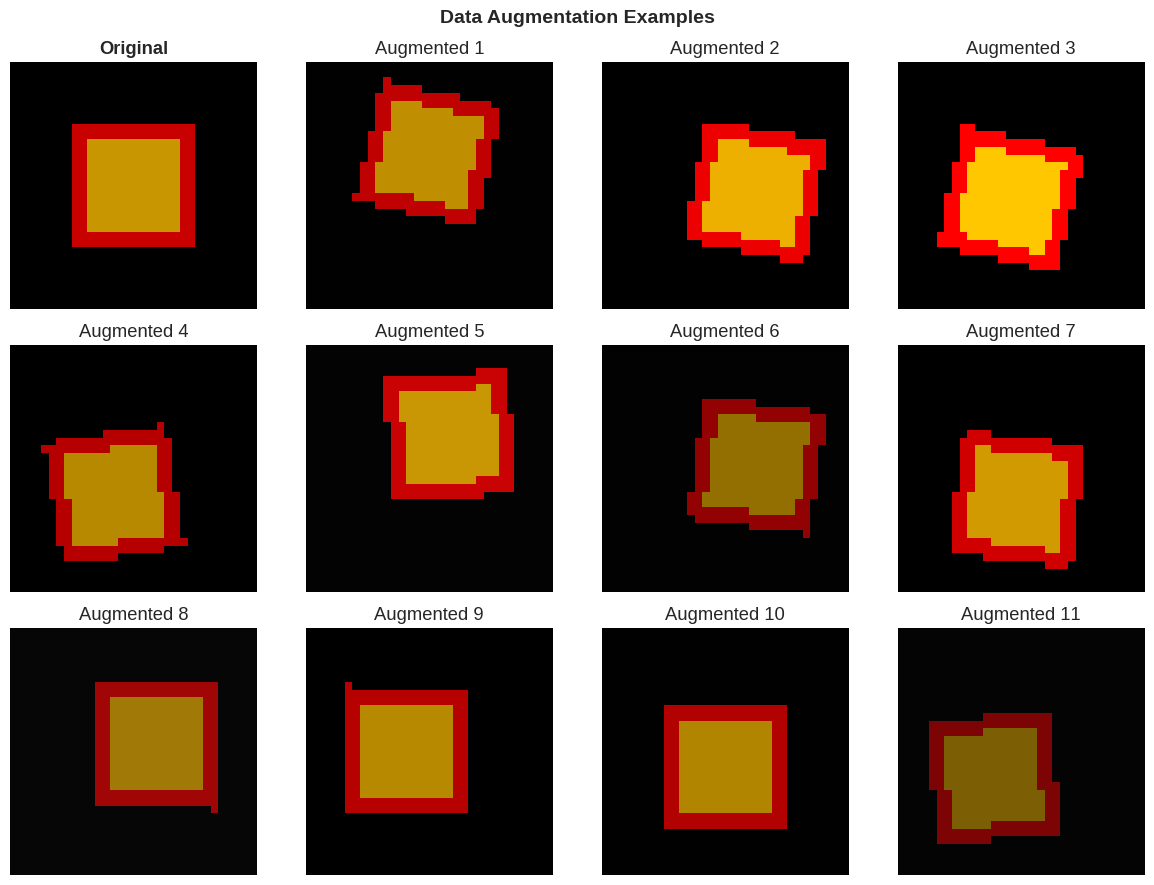


 Each augmented image is a 'new' training sample!
 This effectively increases dataset size and reduces overfitting.


In [14]:
# ============================================================================
#                   VISUALIZE AUGMENTATIONS
# ============================================================================

# Create a sample image
sample_img = np.zeros((32, 32, 3), dtype=np.uint8)
sample_img[8:24, 8:24, 0] = 200  # Red square
sample_img[10:22, 10:22, 1] = 150  # Green inner square
sample_img = Image.fromarray(sample_img)

# Augmentation transforms for visualization (without normalize)
aug_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
])

# Show augmented versions
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes[0, 0].imshow(sample_img)
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

for i, ax in enumerate(axes.flatten()[1:]):
    augmented = aug_transforms(sample_img)
    ax.imshow(augmented)
    ax.set_title(f'Augmented {i+1}')
    ax.axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Each augmented image is a 'new' training sample!")
print(" This effectively increases dataset size and reduces overfitting.")

              CIFAR-10 DATASET


100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]



Dataset Statistics:
  Training samples:   50,000
  Test samples:       10,000
  Image shape:        3 x 32 x 32 (RGB)
  Number of classes:  10
  Classes: ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


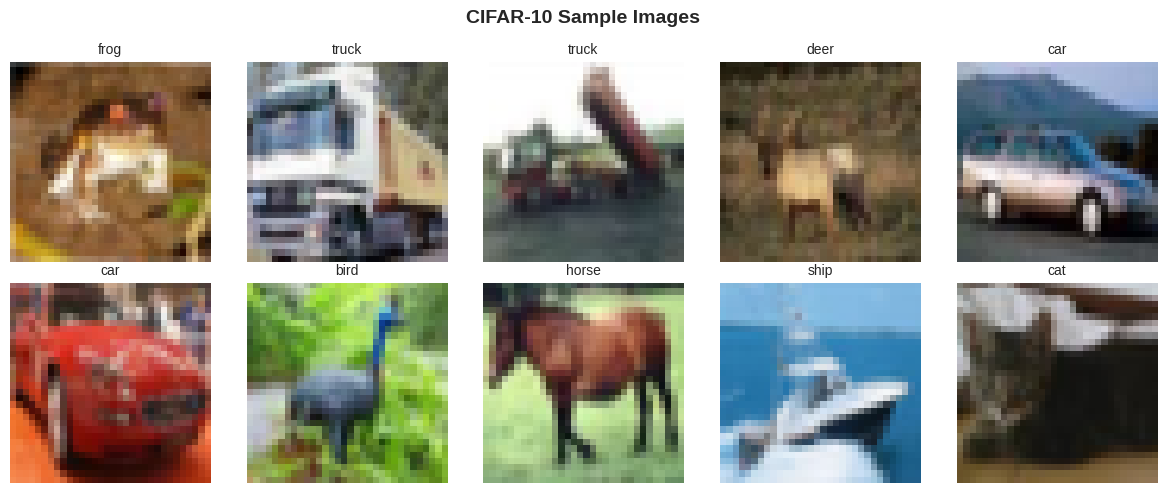

In [15]:
# ============================================================================
#                       LOAD CIFAR-10 DATASET
# ============================================================================

print("="*60)
print("              CIFAR-10 DATASET")
print("="*60)

# Download and load CIFAR-10
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transforms
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=val_transforms
)

# Class names
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f"\nDataset Statistics:")
print(f"  Training samples:   {len(train_dataset):,}")
print(f"  Test samples:       {len(test_dataset):,}")
print(f"  Image shape:        3 x 32 x 32 (RGB)")
print(f"  Number of classes:  {len(classes)}")
print(f"  Classes: {classes}")

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

# Show sample images
# Get raw images without normalization for visualization
viz_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False,
    transform=transforms.ToTensor()
)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    img, label = viz_dataset[i]
    ax.imshow(img.permute(1, 2, 0))  # CHW → HWC
    ax.set_title(classes[label], fontsize=10)
    ax.axis('off')

plt.suptitle('CIFAR-10 Sample Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# ============================================================================
#                    COMPLETE TRAINING PIPELINE
# ============================================================================

def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)

        # Forward
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # Backward
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    return running_loss / total, 100. * correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate the model."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    return running_loss / total, 100. * correct / total


def train_cnn(model, train_loader, test_loader, epochs=20, lr=0.001):
    """
    Complete CNN training with:
    - Cross-entropy loss
    - Adam optimizer
    - Learning rate scheduling
    - Training history tracking
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Removed 'verbose' argument as it is deprecated/removed in modern PyTorch
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, test_loader, criterion, device)

        # Learning rate scheduling
        scheduler.step(val_acc)

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc

        # Record history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1:3d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    print(f"\nBest Validation Accuracy: {best_acc:.2f}%")
    return history


print("Training functions defined!")

Training functions defined!


In [17]:
# ============================================================================
#                    TRAIN THE MODEL
# ============================================================================

print("="*60)
print("           TRAINING MODERN CNN ON CIFAR-10")
print("="*60)

# Create model
model = ModernCNN(num_classes=10)

print(f"\nModel: ModernCNN")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Device: {device}")

# Train (reduced epochs for demo)
print("\nTraining...\n")
history = train_cnn(model, train_loader, test_loader, epochs=10, lr=0.001)

           TRAINING MODERN CNN ON CIFAR-10

Model: ModernCNN
Parameters: 288,746
Device: cuda

Training...

Epoch   1/10 | Train Loss: 1.7964 | Train Acc: 32.73% | Val Loss: 1.4973 | Val Acc: 44.77%
Epoch   2/10 | Train Loss: 1.5188 | Train Acc: 43.89% | Val Loss: 1.2481 | Val Acc: 55.11%
Epoch   3/10 | Train Loss: 1.3702 | Train Acc: 50.08% | Val Loss: 1.1437 | Val Acc: 58.13%
Epoch   4/10 | Train Loss: 1.2724 | Train Acc: 54.07% | Val Loss: 1.0543 | Val Acc: 61.93%
Epoch   5/10 | Train Loss: 1.1992 | Train Acc: 56.92% | Val Loss: 0.9795 | Val Acc: 64.65%
Epoch   6/10 | Train Loss: 1.1428 | Train Acc: 59.12% | Val Loss: 0.9663 | Val Acc: 65.74%
Epoch   7/10 | Train Loss: 1.0966 | Train Acc: 60.97% | Val Loss: 0.8631 | Val Acc: 69.23%
Epoch   8/10 | Train Loss: 1.0603 | Train Acc: 62.29% | Val Loss: 0.9001 | Val Acc: 68.67%
Epoch   9/10 | Train Loss: 1.0189 | Train Acc: 64.15% | Val Loss: 0.8118 | Val Acc: 71.28%
Epoch  10/10 | Train Loss: 1.0004 | Train Acc: 64.82% | Val Loss: 0.7962 

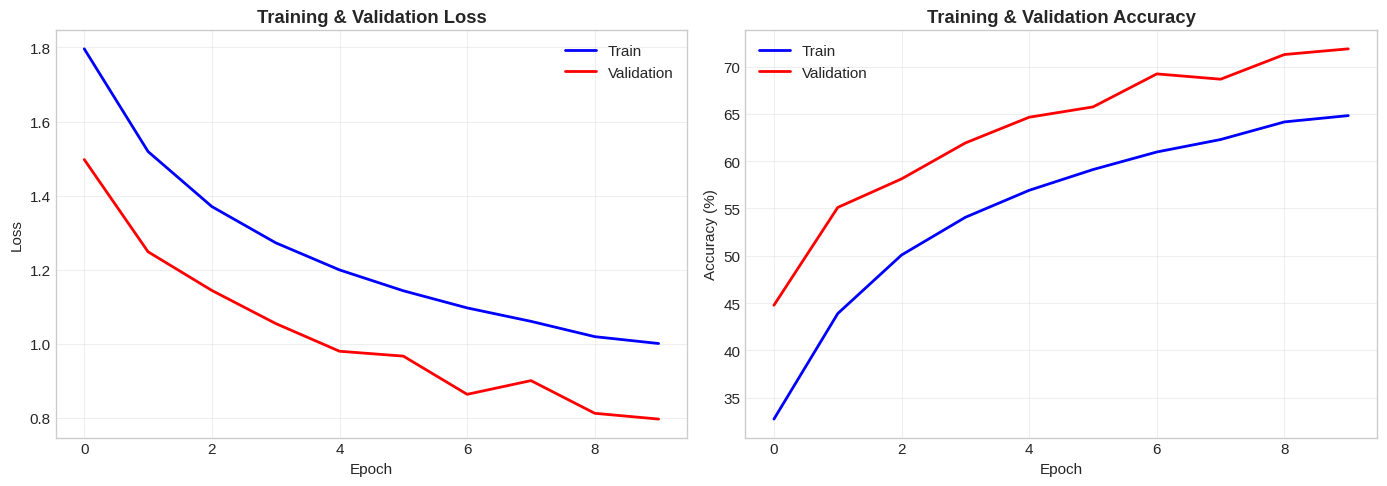

In [18]:
# ============================================================================
#                    PLOT TRAINING HISTORY
# ============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(history['train_loss'], 'b-', linewidth=2, label='Train')
ax1.plot(history['val_loss'], 'r-', linewidth=2, label='Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(history['train_acc'], 'b-', linewidth=2, label='Train')
ax2.plot(history['val_acc'], 'r-', linewidth=2, label='Validation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training & Validation Accuracy', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

# Chapter 6: Visualizing What CNNs Learn

## Understanding the Black Box

CNNs learn hierarchical features:

```
Layer 1 (edges, colors)  →  Layer 2 (textures)  →  Layer 3 (parts)  →  Layer 4 (objects)

   /  |  \                  /|\  ___           👁️ 👂               🐱 🐶 🚗
  |   |   |                 ||| ~~~             face               cat dog car
```

           VISUALIZING LEARNED FILTERS


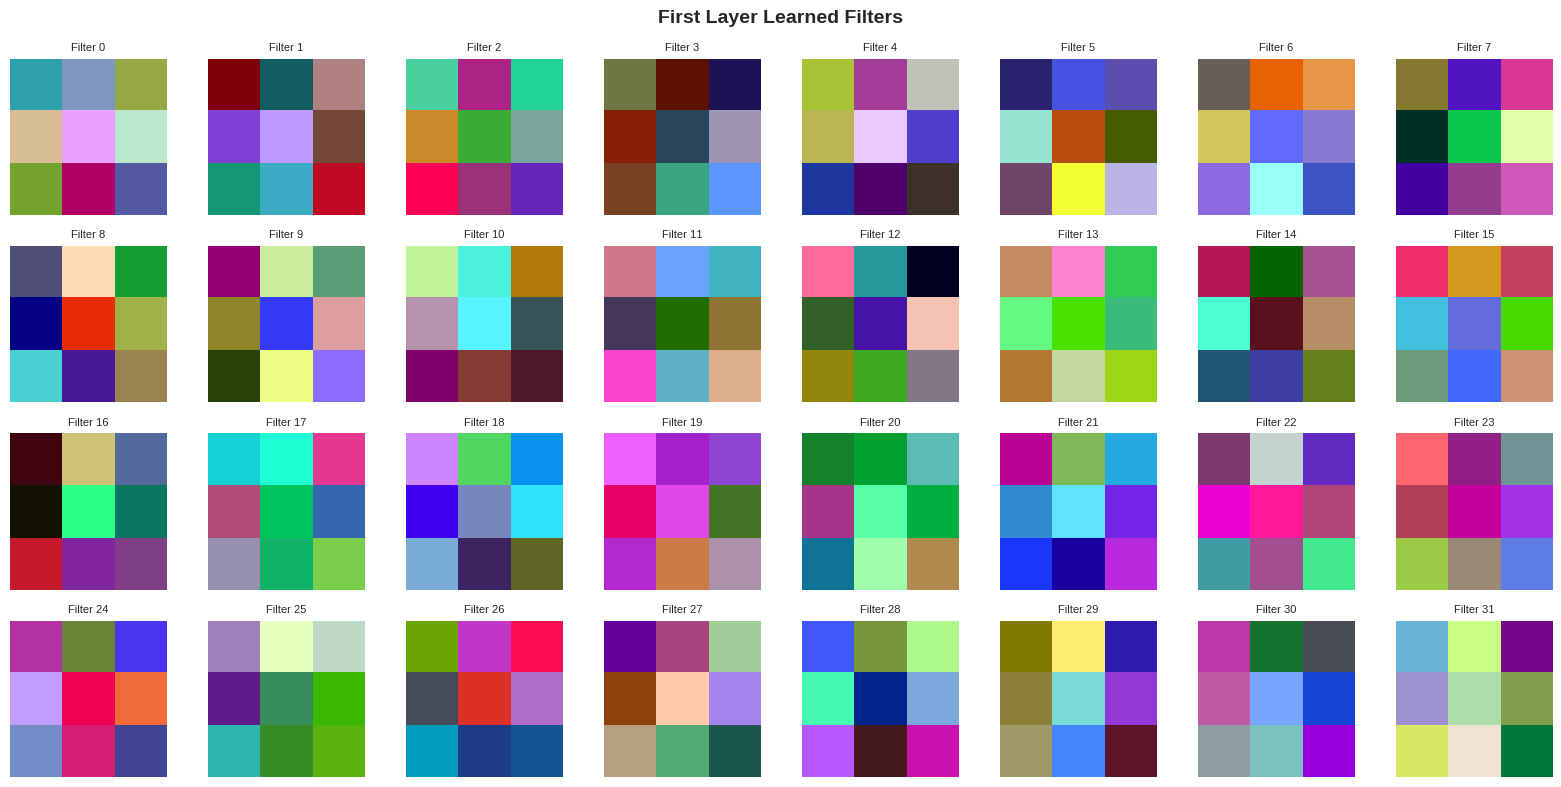


 First layer filters typically learn edge and color detectors.
 They look similar to hand-crafted Gabor filters!


In [19]:
# ============================================================================
#                    VISUALIZE LEARNED FILTERS
# ============================================================================

print("="*60)
print("           VISUALIZING LEARNED FILTERS")
print("="*60)

def visualize_filters(model, layer_name='features.0.block.0'):
    """
    Visualize the learned filters from the first conv layer.
    """
    # Get the first conv layer weights
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            weights = module.weight.detach().cpu()
            break

    # Normalize weights for visualization
    n_filters = min(weights.shape[0], 32)

    fig, axes = plt.subplots(4, 8, figsize=(16, 8))

    for i, ax in enumerate(axes.flatten()):
        if i >= n_filters:
            ax.axis('off')
            continue

        # Get filter and normalize
        filt = weights[i]
        if filt.shape[0] == 3:  # RGB
            filt = filt.permute(1, 2, 0)  # CHW → HWC
            filt = (filt - filt.min()) / (filt.max() - filt.min())
            ax.imshow(filt.numpy())
        else:  # Grayscale
            ax.imshow(filt[0].numpy(), cmap='gray')

        ax.set_title(f'Filter {i}', fontsize=8)
        ax.axis('off')

    plt.suptitle('First Layer Learned Filters', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


visualize_filters(model)

print("\n First layer filters typically learn edge and color detectors.")
print(" They look similar to hand-crafted Gabor filters!")


Visualizing feature maps for a 'cat'


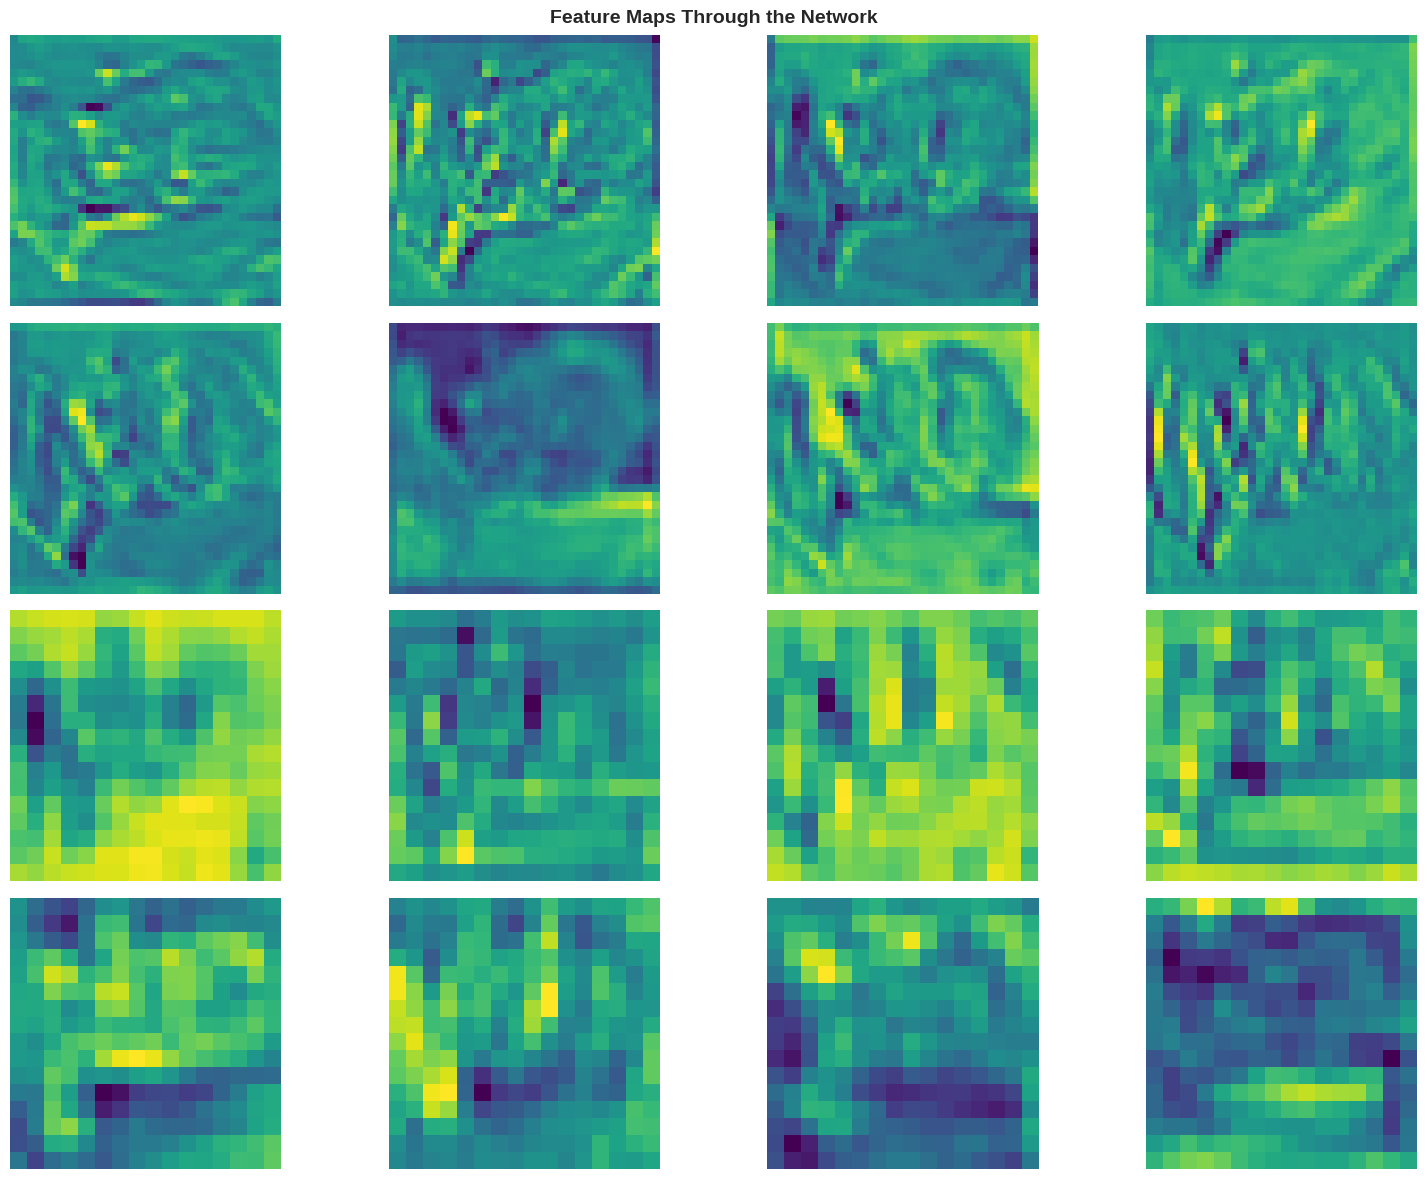


 Notice how:
 - Early layers: detect simple edges and colors
 - Middle layers: combine into textures and patterns
 - Late layers: represent high-level semantic features


In [20]:
# ============================================================================
#                    VISUALIZE FEATURE MAPS
# ============================================================================

def visualize_feature_maps(model, image, max_maps=16):
    """
    Visualize feature maps at different layers.
    """
    model.eval()

    # Hook to capture feature maps
    feature_maps = []
    hooks = []

    def hook_fn(module, input, output):
        feature_maps.append(output.detach())

    # Register hooks on conv layers
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            hooks.append(module.register_forward_hook(hook_fn))

    # Forward pass
    with torch.no_grad():
        _ = model(image.unsqueeze(0).to(device))

    # Remove hooks
    for hook in hooks:
        hook.remove()

    # Visualize
    n_layers = min(len(feature_maps), 4)
    fig, axes = plt.subplots(n_layers, max_maps // 4, figsize=(16, n_layers * 3))

    for layer_idx in range(n_layers):
        # Fix: Use direct indexing or ensure index is within range
        fmaps = feature_maps[layer_idx].squeeze().cpu()
        n_maps = min(fmaps.shape[0], max_maps // 4)

        for map_idx in range(n_maps):
            ax = axes[layer_idx, map_idx] if n_layers > 1 else axes[map_idx]
            ax.imshow(fmaps[map_idx].numpy(), cmap='viridis')
            ax.axis('off')
            if map_idx == 0:
                ax.set_ylabel(f'Layer {layer_idx + 1}', fontsize=10)

    plt.suptitle('Feature Maps Through the Network', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return feature_maps


# Get a sample image
sample_img, sample_label = test_dataset[0]

print(f"\nVisualizing feature maps for a '{classes[sample_label]}'")
fmaps = visualize_feature_maps(model, sample_img)

print("\n Notice how:")
print(" - Early layers: detect simple edges and colors")
print(" - Middle layers: combine into textures and patterns")
print(" - Late layers: represent high-level semantic features")

---

# Chapter 7: Building a Complete Image Classifier

## Production-Ready CNN for CIFAR-10

Let's build a more sophisticated CNN with all modern best practices.

In [21]:
# ============================================================================
#                    PRODUCTION CNN ARCHITECTURE
# ============================================================================

class ProductionCNN(nn.Module):
    """
    Production-ready CNN with modern best practices:

    1. Increasing channel depth: 64 → 128 → 256 → 512
    2. Batch normalization everywhere
    3. Dropout for regularization
    4. Global average pooling (parameter efficient)
    5. Proper weight initialization
    """

    def __init__(self, num_classes: int = 10, dropout: float = 0.3):
        super().__init__()

        def conv_block(in_ch, out_ch, pool=True):
            layers = [
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            if pool:
                layers.append(nn.MaxPool2d(2))
            return nn.Sequential(*layers)

        self.features = nn.Sequential(
            conv_block(3, 64),        # 32 → 16
            nn.Dropout2d(dropout),

            conv_block(64, 128),      # 16 → 8
            nn.Dropout2d(dropout),

            conv_block(128, 256),     # 8 → 4
            nn.Dropout2d(dropout),

            conv_block(256, 512, pool=False),  # Keep at 4x4
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

        # Initialize weights
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Create and summarize
prod_model = ProductionCNN(num_classes=10, dropout=0.3)
total_params = sum(p.numel() for p in prod_model.parameters())

print("="*60)
print("           PRODUCTION CNN ARCHITECTURE")
print("="*60)
print(prod_model)
print(f"\nTotal Parameters: {total_params:,}")

# Test
x = torch.randn(2, 3, 32, 32)
y = prod_model(x)
print(f"\nInput: {x.shape} → Output: {y.shape}")

           PRODUCTION CNN ARCHITECTURE
ProductionCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Dropout2d(p=0.3, inplace=False)
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(

In [22]:
# ============================================================================
#                    ADVANCED TRAINING FEATURES
# ============================================================================

def train_advanced(model, train_loader, test_loader, epochs=30, lr=0.001):
    """
    Advanced training with:
    - Learning rate warmup
    - Cosine annealing
    - Gradient clipping
    - Early stopping
    - Model checkpointing
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    # Cosine annealing scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    best_acc = 0
    patience = 5
    no_improve = 0

    for epoch in range(epochs):
        # Training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        train_loss = running_loss / total
        train_acc = 100. * correct / total

        # Validation
        val_loss, val_acc = evaluate(model, test_loader, criterion, device)

        # Update scheduler
        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

        # Record history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        # Early stopping check
        if val_acc > best_acc:
            best_acc = val_acc
            no_improve = 0
            # Save best model
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            no_improve += 1

        print(f"Epoch {epoch+1:3d}/{epochs} | LR: {current_lr:.6f} | "
              f"Train: {train_acc:.2f}% | Val: {val_acc:.2f}% | Best: {best_acc:.2f}%")

        if no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    print(f"\nBest Validation Accuracy: {best_acc:.2f}%")
    return history


print("Advanced training function defined!")

Advanced training function defined!


In [23]:
# ============================================================================
#                    TRAIN PRODUCTION MODEL
# ============================================================================

print("="*60)
print("           TRAINING PRODUCTION CNN")
print("="*60)

# Create fresh model
prod_model = ProductionCNN(num_classes=10, dropout=0.3)

print(f"\nModel Parameters: {sum(p.numel() for p in prod_model.parameters()):,}")
print(f"Device: {device}")
print("\nTraining with advanced features...\n")

# Train (reduced epochs for demo)
history = train_advanced(prod_model, train_loader, test_loader, epochs=15, lr=0.001)

           TRAINING PRODUCTION CNN

Model Parameters: 4,692,426
Device: cuda

Training with advanced features...

Epoch   1/15 | LR: 0.000989 | Train: 35.03% | Val: 49.72% | Best: 49.72%
Epoch   2/15 | LR: 0.000957 | Train: 47.53% | Val: 58.11% | Best: 58.11%
Epoch   3/15 | LR: 0.000905 | Train: 54.25% | Val: 62.30% | Best: 62.30%
Epoch   4/15 | LR: 0.000835 | Train: 59.30% | Val: 66.33% | Best: 66.33%
Epoch   5/15 | LR: 0.000750 | Train: 62.57% | Val: 70.32% | Best: 70.32%
Epoch   6/15 | LR: 0.000655 | Train: 65.73% | Val: 73.76% | Best: 73.76%
Epoch   7/15 | LR: 0.000552 | Train: 68.02% | Val: 75.15% | Best: 75.15%
Epoch   8/15 | LR: 0.000448 | Train: 69.62% | Val: 77.56% | Best: 77.56%
Epoch   9/15 | LR: 0.000345 | Train: 71.36% | Val: 78.56% | Best: 78.56%
Epoch  10/15 | LR: 0.000250 | Train: 72.68% | Val: 79.30% | Best: 79.30%
Epoch  11/15 | LR: 0.000165 | Train: 73.99% | Val: 80.50% | Best: 80.50%
Epoch  12/15 | LR: 0.000095 | Train: 74.72% | Val: 80.30% | Best: 80.50%
Epoch  13/

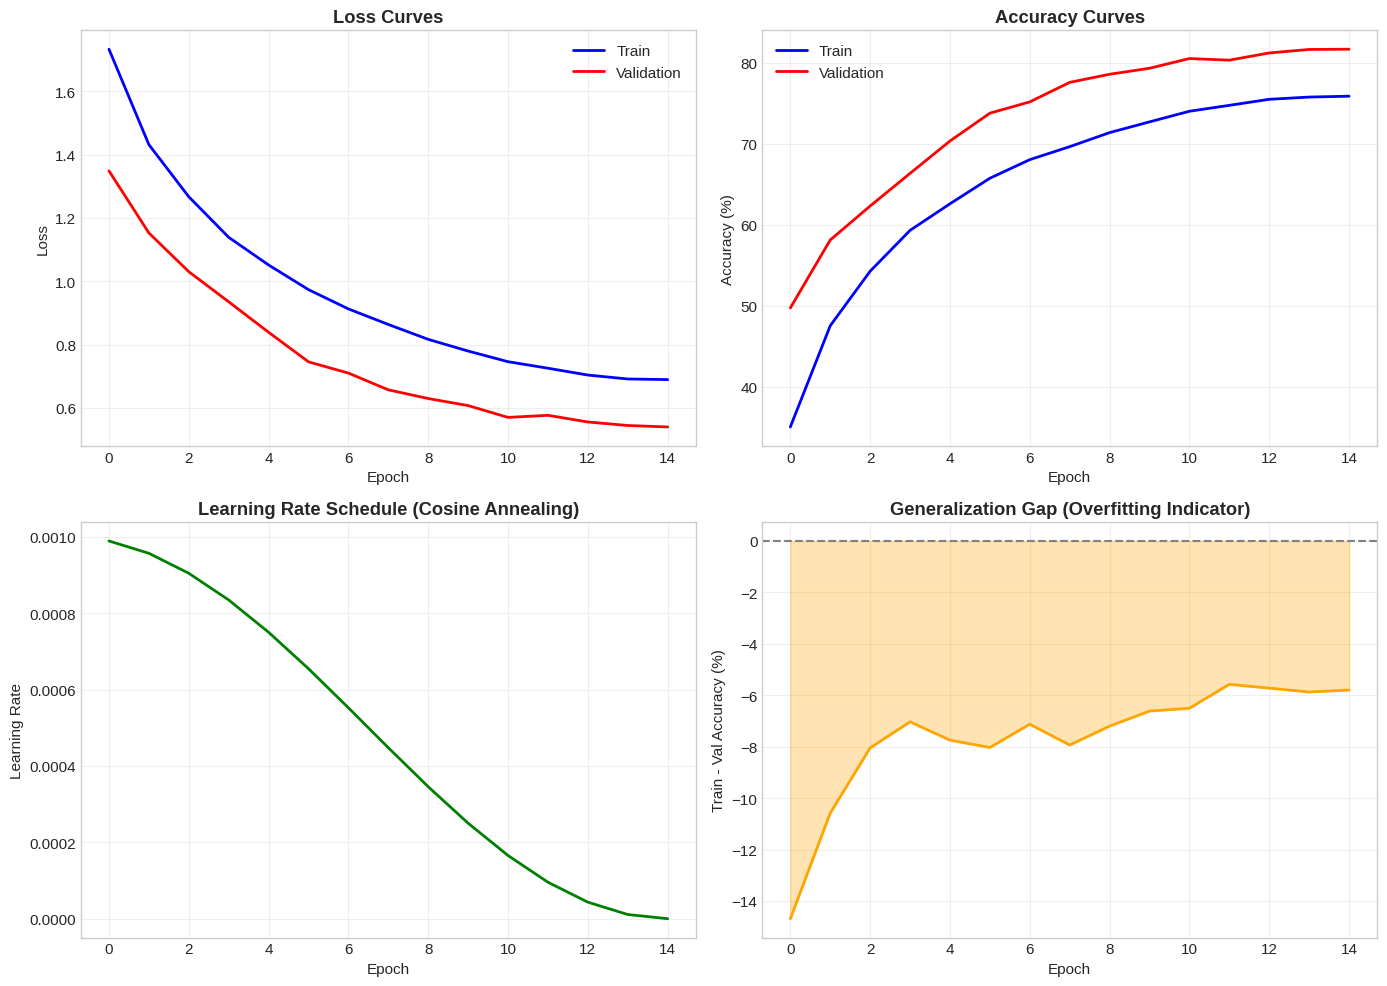

In [24]:
# ============================================================================
#                    COMPREHENSIVE RESULTS
# ============================================================================

# Plot everything
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(history['train_loss'], 'b-', linewidth=2, label='Train')
axes[0, 0].plot(history['val_loss'], 'r-', linewidth=2, label='Validation')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(history['train_acc'], 'b-', linewidth=2, label='Train')
axes[0, 1].plot(history['val_acc'], 'r-', linewidth=2, label='Validation')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Accuracy Curves', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Learning rate
axes[1, 0].plot(history['lr'], 'g-', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_title('Learning Rate Schedule (Cosine Annealing)', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Train vs Val gap (overfitting indicator)
gap = [t - v for t, v in zip(history['train_acc'], history['val_acc'])]
axes[1, 1].fill_between(range(len(gap)), gap, alpha=0.3, color='orange')
axes[1, 1].plot(gap, 'orange', linewidth=2)
axes[1, 1].axhline(y=0, color='gray', linestyle='--')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Train - Val Accuracy (%)')
axes[1, 1].set_title('Generalization Gap (Overfitting Indicator)', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Analyzing model predictions...



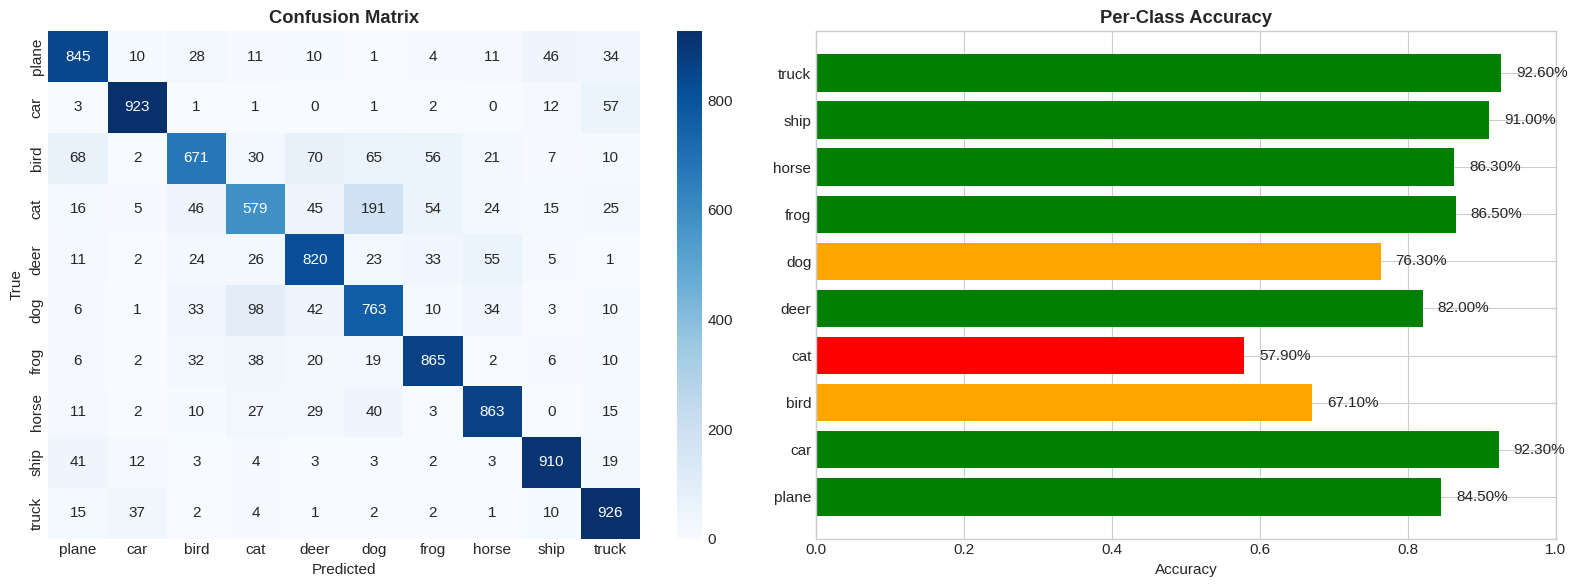


Classification Report:
              precision    recall  f1-score   support

       plane       0.83      0.84      0.84      1000
         car       0.93      0.92      0.92      1000
        bird       0.79      0.67      0.73      1000
         cat       0.71      0.58      0.64      1000
        deer       0.79      0.82      0.80      1000
         dog       0.69      0.76      0.72      1000
        frog       0.84      0.86      0.85      1000
       horse       0.85      0.86      0.86      1000
        ship       0.90      0.91      0.90      1000
       truck       0.84      0.93      0.88      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.81     10000
weighted avg       0.82      0.82      0.81     10000



In [25]:
# ============================================================================
#                    CONFUSION MATRIX & ANALYSIS
# ============================================================================

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def analyze_predictions(model, test_loader, classes):
    """Comprehensive prediction analysis."""
    model.eval()
    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            _, preds = outputs.max(1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    all_probs = np.array(all_probs)

    # Confusion matrix
    cm = confusion_matrix(all_targets, all_preds)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Confusion matrix heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=classes, yticklabels=classes)
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('True')
    ax1.set_title('Confusion Matrix', fontweight='bold')

    # Per-class accuracy
    class_acc = cm.diagonal() / cm.sum(axis=1)
    colors = ['green' if acc > 0.8 else 'orange' if acc > 0.6 else 'red' for acc in class_acc]
    ax2.barh(classes, class_acc, color=colors)
    ax2.set_xlabel('Accuracy')
    ax2.set_title('Per-Class Accuracy', fontweight='bold')
    ax2.set_xlim(0, 1)
    for i, acc in enumerate(class_acc):
        ax2.text(acc + 0.02, i, f'{acc:.2%}', va='center')

    plt.tight_layout()
    plt.show()

    # Print classification report
    print("\nClassification Report:")
    print(classification_report(all_targets, all_preds, target_names=classes))

    return all_preds, all_targets, all_probs


# Load best model
prod_model.load_state_dict(torch.load('best_model.pth'))

print("\nAnalyzing model predictions...\n")
preds, targets, probs = analyze_predictions(prod_model, test_loader, classes)

---

# Summary: CNN Building Blocks

## What We Built

| Component | Purpose | Key Insights |
|-----------|---------|-------------|
| **Convolution** | Feature extraction | Local patterns, parameter sharing |
| **Pooling** | Downsampling | Translation invariance, receptive field |
| **BatchNorm** | Normalization | Faster training, regularization |
| **Dropout** | Regularization | Prevents overfitting |
| **Global AvgPool** | Dimension reduction | No FC layer explosion |

## CNN Design Rules

1. **Double channels when halving spatial size**: 64→32×32 → 128→16×16 → 256→8×8
2. **Start with 3×3 kernels**: Most efficient, stack for larger receptive field
3. **Use BatchNorm after every Conv**: Stabilizes training
4. **End with Global Average Pooling**: Works with any input size
5. **Augment training data heavily**: Key to generalization

## Next Steps

- **Part 2**: Modern architectures (ResNet, EfficientNet, transfer learning)
- **Part 3**: Vision Transformers (ViT, CLIP, DINOv2, SAM)

---

*"The best way to understand CNNs is to build them from scratch."*

**Happy Learning!**

In [26]:
# ============================================================================
#                         CNN CHEAT SHEET
# ============================================================================

print("="*70)
print("                    CNN CHEAT SHEET")
print("="*70)

cheat_sheet = """
CONVOLUTION
-----------
nn.Conv2d(in_ch, out_ch, kernel_size, stride=1, padding=0)

Output size: H_out = (H_in + 2*padding - kernel_size) / stride + 1

Common patterns:
  - Same size:     kernel=3, stride=1, padding=1
  - Halve size:    kernel=3, stride=2, padding=1
  - 7x7 initial:   kernel=7, stride=2, padding=3

POOLING
-------
nn.MaxPool2d(kernel_size, stride=None)     # stride defaults to kernel_size
nn.AvgPool2d(kernel_size, stride=None)
nn.AdaptiveAvgPool2d(output_size)          # Global: output_size=(1,1)

NORMALIZATION
-------------
nn.BatchNorm2d(num_features)   # After conv, before activation
nn.LayerNorm(normalized_shape) # Common in transformers
nn.GroupNorm(num_groups, num_channels)  # Works with small batches

REGULARIZATION
--------------
nn.Dropout(p)       # For FC layers
nn.Dropout2d(p)     # For conv layers (drops entire channels)

MODERN CONV BLOCK
-----------------
Conv2d → BatchNorm → ReLU → Conv2d → BatchNorm → ReLU → Pool

DATA AUGMENTATION
-----------------
transforms.RandomCrop(32, padding=4)
transforms.RandomHorizontalFlip(p=0.5)
transforms.RandomRotation(15)
transforms.ColorJitter(brightness, contrast, saturation)
transforms.Normalize(mean, std)

TRAINING LOOP
-------------
model.train()                 # Enable dropout, batchnorm training mode
optimizer.zero_grad()         # Clear gradients
outputs = model(inputs)       # Forward pass
loss = criterion(outputs, targets)
loss.backward()               # Compute gradients
optimizer.step()              # Update weights

model.eval()                  # Disable dropout, use running stats
with torch.no_grad():         # No gradient computation
    outputs = model(inputs)
"""
print(cheat_sheet)

                    CNN CHEAT SHEET

CONVOLUTION
-----------
nn.Conv2d(in_ch, out_ch, kernel_size, stride=1, padding=0)

Output size: H_out = (H_in + 2*padding - kernel_size) / stride + 1

Common patterns:
  - Same size:     kernel=3, stride=1, padding=1
  - Halve size:    kernel=3, stride=2, padding=1
  - 7x7 initial:   kernel=7, stride=2, padding=3

POOLING
-------
nn.MaxPool2d(kernel_size, stride=None)     # stride defaults to kernel_size
nn.AvgPool2d(kernel_size, stride=None)
nn.AdaptiveAvgPool2d(output_size)          # Global: output_size=(1,1)

NORMALIZATION
-------------
nn.BatchNorm2d(num_features)   # After conv, before activation
nn.LayerNorm(normalized_shape) # Common in transformers
nn.GroupNorm(num_groups, num_channels)  # Works with small batches

REGULARIZATION
--------------
nn.Dropout(p)       # For FC layers
nn.Dropout2d(p)     # For conv layers (drops entire channels)

MODERN CONV BLOCK
-----------------
Conv2d → BatchNorm → ReLU → Conv2d → BatchNorm → ReLU → Pool

D